# Day 1 — Machine Learning Workflow Using Scikit-Learn Only

This notebook contains only **scikit-learn based model building**.


## Projects

| Project | Dataset | Task | Model |
|---|---|---|---|
| Project 1 | Insurance CSV | Regression | Linear Regression |
| Project 2 | Diabetes CSV | Classification | Decision Tree |
| Project 3 | Iris CSV | Clustering | K-Means |

# Project 1 — Insurance Charge Prediction

## Task

Predict medical insurance `charges`.

## Dataset

Insurance dataset

## Model

Linear Regression

## Step 1 — Import pandas

In [1]:
import pandas as pd

## Step 2 — Give the insurance dataset path

In [2]:
insurance_path = "datasets/insurance.csv"

# Windows example:
# insurance_path = r"C:\Users\Student\Downloads\insurance.csv"

# Google Colab example:
# insurance_path = "/content/insurance.csv"

## Step 3 — Load the insurance dataset

In [3]:
insurance = pd.read_csv(insurance_path)

print("Insurance dataset loaded successfully.")

Insurance dataset loaded successfully.


## Step 4 — Display first five rows

In [4]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,18.0,male,33.770,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,4449.46200
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,no,northwest,3866.85520


## Step 5 — Display last five rows

In [5]:
insurance.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50.0,male,30.97,3.0,no,northwest,10600.5483
1334,18.0,female,31.92,0.0,no,northeast,2205.9808
1335,18.0,female,36.85,0.0,no,southeast,1629.8335
1336,21.0,female,25.80,0.0,no,southwest,2007.9450
1337,61.0,female,29.07,0.0,yes,northwest,29141.3603


## Step 6 — Display rows and columns

In [6]:
print("Rows:", insurance.shape[0])
print("Columns:", insurance.shape[1])

Rows: 1338
Columns: 7


## Step 7 — Display column names

In [7]:
print(insurance.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


## Step 8 — Display data types

In [8]:
insurance.dtypes

age         float64
sex             str
bmi         float64
children    float64
smoker          str
region          str
charges     float64
dtype: object

## Step 9 — Display dataset information

In [9]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1335 non-null   float64
 1   sex       1336 non-null   str    
 2   bmi       1335 non-null   float64
 3   children  1336 non-null   float64
 4   smoker    1336 non-null   str    
 5   region    1336 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(4), str(3)
memory usage: 73.3 KB


## Step 10 — Display statistical description

In [10]:
insurance.describe()

,age,bmi,children,charges
count,1335.000000,1335.000000,1336.000000,1337.000000
mean,39.238951,30.657903,1.096557,13271.853650
std,14.047648,6.101257,1.205650,12114.429349
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.255000,0.000000,4738.268200
50%,39.000000,30.400000,1.000000,9377.904700
75%,51.000000,34.637500,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


## Step 11 — Identify input and target variables

In [11]:
insurance_input_columns = [
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region"
]

insurance_target_column = "charges"

print("Input variables:", insurance_input_columns)
print("Target variable:", insurance_target_column)

Input variables: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target variable: charges


## Step 12 — Check duplicate rows

In [12]:
print("Duplicate rows:", insurance.duplicated().sum())

Duplicate rows: 1


## Step 13 — Remove duplicate rows

In [13]:
insurance = insurance.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", insurance.shape)

Shape after removing duplicates: (1337, 7)


## Step 14 — Check missing values


In [14]:
insurance.isnull().sum()

age         3
sex         2
bmi         3
children    2
smoker      2
region      2
charges     1
dtype: int64

## Step 15 — Plot numerical data to check skewness

Use this rule:

- Skewness between `-0.5` and `0.5` → use **mean**
- Skewness less than `-0.5` or greater than `0.5` → use **median**
- Categorical column → use **mode**

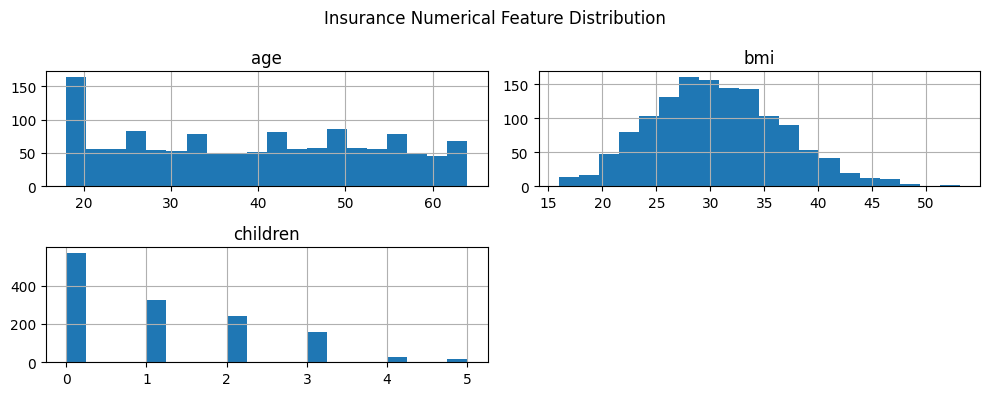

In [15]:
import matplotlib.pyplot as plt

insurance_numeric_columns = [
    "age",
    "bmi",
    "children"
]

insurance[insurance_numeric_columns].hist(
    bins=20,
    figsize=(10, 4)
)

plt.suptitle("Insurance Numerical Feature Distribution")
plt.tight_layout()
plt.show()

## Step 16 — Calculate skewness

In [16]:
insurance[insurance_numeric_columns].skew()

age         0.051264
bmi         0.286014
children    0.935500
dtype: float64

## Step 17 — Decide mean or median

In [17]:
for column in insurance_numeric_columns:
    skew_value = insurance[column].skew()

    if -0.5 <= skew_value <= 0.5:
        print(column, "-> Use mean")
    else:
        print(column, "-> Use median")

age -> Use mean
bmi -> Use mean
children -> Use median


## Step 18 — Fill numerical missing values

In [18]:
insurance["age"] = insurance["age"].fillna(
    insurance["age"].mean()
)

insurance["bmi"] = insurance["bmi"].fillna(
    insurance["bmi"].mean()
)

insurance["children"] = insurance["children"].fillna(
    insurance["children"].median()
)

## Step 19 — Fill categorical missing values using mode

In [19]:
insurance["sex"] = insurance["sex"].fillna(
    insurance["sex"].mode()[0]
)

insurance["smoker"] = insurance["smoker"].fillna(
    insurance["smoker"].mode()[0]
)

insurance["region"] = insurance["region"].fillna(
    insurance["region"].mode()[0]
)

## Step 20 — Remove rows where target value is missing

In [20]:
insurance = insurance.dropna(subset=["charges"])

## Step 21 — Verify missing values

In [21]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Step 22 — Encode categorical columns

In [22]:
insurance_encoded = pd.get_dummies(
    insurance,
    columns=["sex", "smoker", "region"],
    dtype=int
)

insurance_encoded.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,16884.92400,1,0,0,1,0,0,0,1
1,18.0,33.770,1.0,1725.55230,0,1,1,0,0,0,1,0
2,28.0,33.000,3.0,4449.46200,0,1,1,0,0,0,1,0
3,33.0,22.705,0.0,21984.47061,0,1,1,0,0,1,0,0
4,32.0,28.880,0.0,3866.85520,0,1,1,0,0,1,0,0


## Step 23 — Separate input and target variables

In [23]:
X_insurance = insurance_encoded.drop(
    "charges",
    axis=1
)

y_insurance = insurance_encoded["charges"]

print("Input shape:", X_insurance.shape)
print("Target shape:", y_insurance.shape)

Input shape: (1336, 11)
Target shape: (1336,)


## Step 24 — Split training and testing data

In [24]:
from sklearn.model_selection import train_test_split

X_train_insurance, X_test_insurance, y_train_insurance, y_test_insurance = train_test_split(
    X_insurance,
    y_insurance,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train_insurance.shape[0])
print("Testing rows:", X_test_insurance.shape[0])

Training rows: 1068
Testing rows: 268


## Step 25 — Standardize numerical columns

In [25]:
from sklearn.preprocessing import StandardScaler

insurance_scaler = StandardScaler()

scale_columns = [
    "age",
    "bmi",
    "children"
]

X_train_insurance_scaled = X_train_insurance.copy()
X_test_insurance_scaled = X_test_insurance.copy()

X_train_insurance_scaled[scale_columns] = insurance_scaler.fit_transform(
    X_train_insurance[scale_columns]
)

X_test_insurance_scaled[scale_columns] = insurance_scaler.transform(
    X_test_insurance[scale_columns]
)

# Build Linear Regression Model

## Step 26 — Import and create Linear Regression model

In [26]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

## Step 27 — Train the model

In [27]:
linear_model.fit(
    X_train_insurance_scaled,
    y_train_insurance
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Step 28 — Predict test data

In [28]:
insurance_predictions = linear_model.predict(
    X_test_insurance_scaled
)

## Step 29 — Compare actual and predicted values

In [29]:
insurance_result = pd.DataFrame({
    "Actual Charges": y_test_insurance.values,
    "Predicted Charges": insurance_predictions
})

insurance_result.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8392.951121
1,5708.86700,5425.272329
2,11436.73815,14582.807279
3,9249.49520,10257.781703
4,17352.68030,26085.919365
5,1622.18850,2057.528180
6,5354.07465,4609.143440
7,12928.79110,14048.323478
8,9140.95100,11841.734730
9,10264.44210,11664.107516


## Step 30 — Evaluate the model

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    y_test_insurance,
    insurance_predictions
)

mse = mean_squared_error(
    y_test_insurance,
    insurance_predictions
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test_insurance,
    insurance_predictions
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4331.875132152566
MSE: 40197109.01046901
RMSE: 6340.119006017869
R2 Score: 0.7346743443721404


## Step 31 — Plot actual vs predicted values

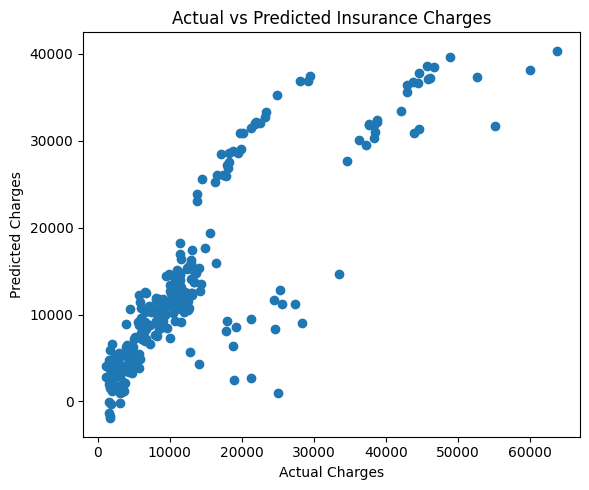

In [31]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test_insurance,
    insurance_predictions
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.tight_layout()
plt.show()

# Predict Insurance Charges for Unknown Customer

## Step 32 — Create unknown customer data

In [32]:
new_customer = pd.DataFrame({
    "age": [35],
    "sex": ["male"],
    "bmi": [27.5],
    "children": [2],
    "smoker": ["no"],
    "region": ["southeast"]
})

new_customer

,age,sex,bmi,children,smoker,region
0,35,male,27.5,2,no,southeast


## Step 33 — Encode unknown customer data

In [33]:
new_customer_encoded = pd.get_dummies(
    new_customer,
    columns=["sex", "smoker", "region"],
    dtype=int
)

new_customer_encoded = new_customer_encoded.reindex(
    columns=X_insurance.columns,
    fill_value=0
)

## Step 34 — Standardize unknown customer data

In [34]:
new_customer_encoded[scale_columns] = insurance_scaler.transform(
    new_customer_encoded[scale_columns]
)

## Step 35 — Predict unknown customer insurance charge

In [35]:
unknown_customer_prediction = linear_model.predict(
    new_customer_encoded
)[0]

print("Predicted insurance charge:", unknown_customer_prediction)

Predicted insurance charge: 6439.495468281699


# Project 2 — Diabetes Classification

## Task

Predict whether a patient has diabetes.

## Dataset

Diabetes dataset

## Model

Decision Tree Classifier

## Step 1 — Give the diabetes dataset path

In [36]:
diabetes_path = "datasets/diabetes.csv"

# Windows example:
# diabetes_path = r"C:\Users\Student\Downloads\diabetes.csv"

## Step 2 — Give column names

In [37]:
diabetes_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

## Step 3 — Load the diabetes dataset

In [38]:
diabetes = pd.read_csv(
    diabetes_path,
    names=diabetes_columns
)

print("Diabetes dataset loaded successfully.")

Diabetes dataset loaded successfully.


## Step 4 — Display first five rows

In [39]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 5 — Display last five rows

In [40]:
diabetes.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


## Step 6 — Display rows and columns

In [41]:
print("Rows:", diabetes.shape[0])
print("Columns:", diabetes.shape[1])

Rows: 768
Columns: 9


## Step 7 — Display column names

In [42]:
print(diabetes.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## Step 8 — Display data types

In [43]:
diabetes.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

## Step 9 — Display dataset information

In [44]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Step 10 — Display statistical description

In [45]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 11 — Identify input and target variables

In [46]:
diabetes_input_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

diabetes_target_column = "Outcome"

print("Input variables:", diabetes_input_columns)
print("Target variable:", diabetes_target_column)

Input variables: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target variable: Outcome


## Step 12 — Check and remove duplicate rows

In [47]:
print("Duplicate rows:", diabetes.duplicated().sum())

diabetes = diabetes.drop_duplicates()

Duplicate rows: 0


## Step 13 — Convert invalid zero values into missing values

In this dataset, zero is invalid for:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

In [48]:
import numpy as np

invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

diabetes[invalid_zero_columns] = diabetes[invalid_zero_columns].replace(
    0,
    np.nan
)

## Step 14 — Check missing values

In [49]:
diabetes.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## Step 15 — Plot numerical distribution

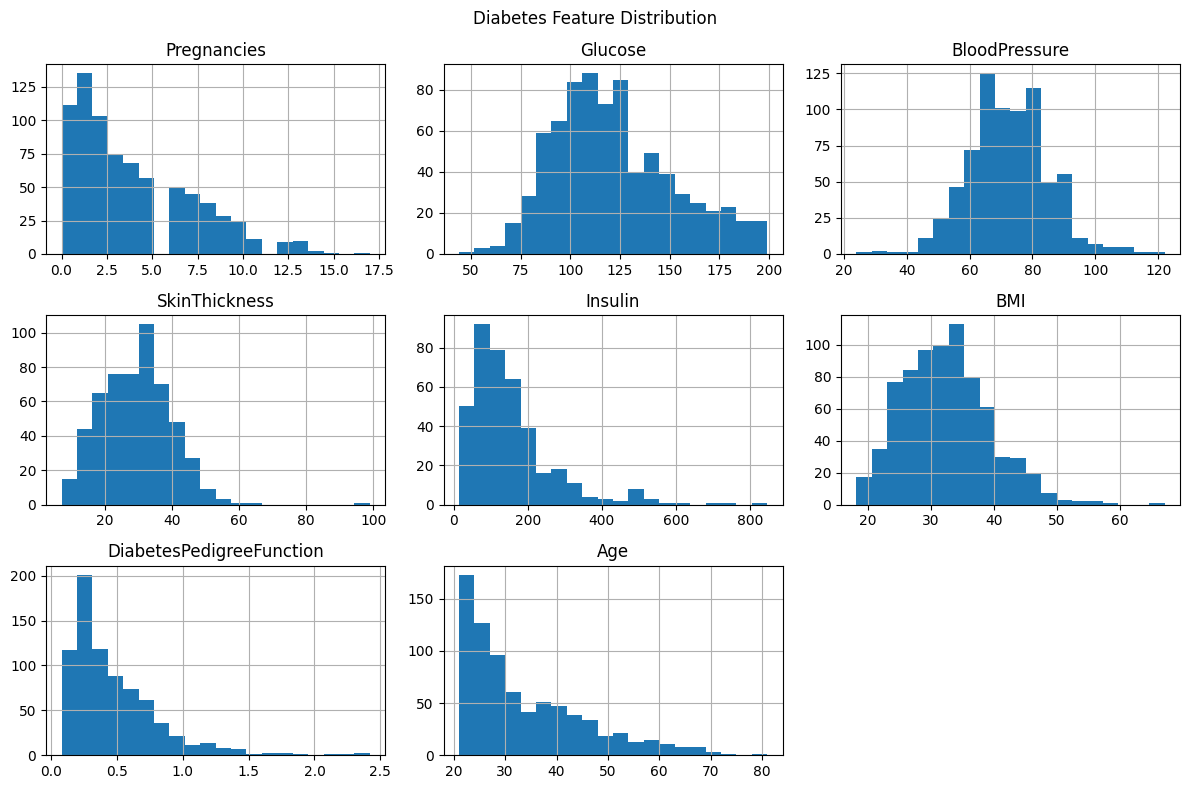

In [50]:
diabetes[diabetes_input_columns].hist(
    bins=20,
    figsize=(12, 8)
)

plt.suptitle("Diabetes Feature Distribution")
plt.tight_layout()
plt.show()

## Step 16 — Calculate skewness

In [51]:
diabetes[diabetes_input_columns].skew()

Pregnancies                 0.901674
Glucose                     0.530989
BloodPressure               0.134153
SkinThickness               0.690619
Insulin                     2.166464
BMI                         0.593970
DiabetesPedigreeFunction    1.919911
Age                         1.129597
dtype: float64

## Step 17 — Decide mean or median

In [52]:
for column in diabetes_input_columns:
    skew_value = diabetes[column].skew()

    if -0.5 <= skew_value <= 0.5:
        print(column, "-> Use mean")
    else:
        print(column, "-> Use median")

Pregnancies -> Use median
Glucose -> Use median
BloodPressure -> Use mean
SkinThickness -> Use median
Insulin -> Use median
BMI -> Use median
DiabetesPedigreeFunction -> Use median
Age -> Use median


## Step 18 — Fill missing values

In [53]:
diabetes["Glucose"] = diabetes["Glucose"].fillna(
    diabetes["Glucose"].median()
)

diabetes["BloodPressure"] = diabetes["BloodPressure"].fillna(
    diabetes["BloodPressure"].mean()
)

diabetes["SkinThickness"] = diabetes["SkinThickness"].fillna(
    diabetes["SkinThickness"].median()
)

diabetes["Insulin"] = diabetes["Insulin"].fillna(
    diabetes["Insulin"].median()
)

diabetes["BMI"] = diabetes["BMI"].fillna(
    diabetes["BMI"].median()
)

## Step 19 — Verify missing values

In [54]:
diabetes.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Step 20 — Check class distribution

In [55]:
diabetes["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Step 21 — Plot class distribution

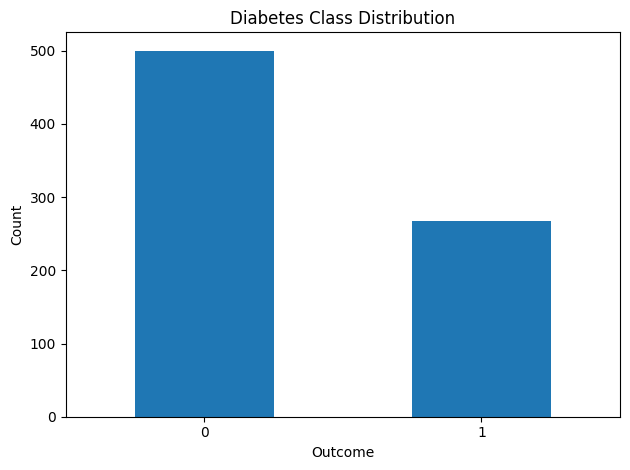

In [56]:
diabetes["Outcome"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Diabetes Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 22 — Separate input and target variables

In [57]:
X_diabetes = diabetes.drop(
    "Outcome",
    axis=1
)

y_diabetes = diabetes["Outcome"]

## Step 23 — Split training and testing data

In [58]:
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.20,
    random_state=42,
    stratify=y_diabetes
)

print("Training rows:", X_train_diabetes.shape[0])
print("Testing rows:", X_test_diabetes.shape[0])

Training rows: 614
Testing rows: 154


# Build Decision Tree Classifier

## Step 24 — Import and create Decision Tree model

In [59]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=42
)

## Step 25 — Train the model

In [60]:
decision_tree_model.fit(
    X_train_diabetes,
    y_train_diabetes
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Step 26 — Predict test data

In [61]:
diabetes_predictions = decision_tree_model.predict(
    X_test_diabetes
)

## Step 27 — Evaluate the model

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

accuracy = accuracy_score(
    y_test_diabetes,
    diabetes_predictions
)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_diabetes,
        diabetes_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_diabetes,
        diabetes_predictions
    )
)

Accuracy: 0.7077922077922078

Confusion Matrix:
[[64 36]
 [ 9 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.64      0.74       100
           1       0.56      0.83      0.67        54

    accuracy                           0.71       154
   macro avg       0.72      0.74      0.70       154
weighted avg       0.76      0.71      0.71       154



## Step 28 — Plot the decision tree

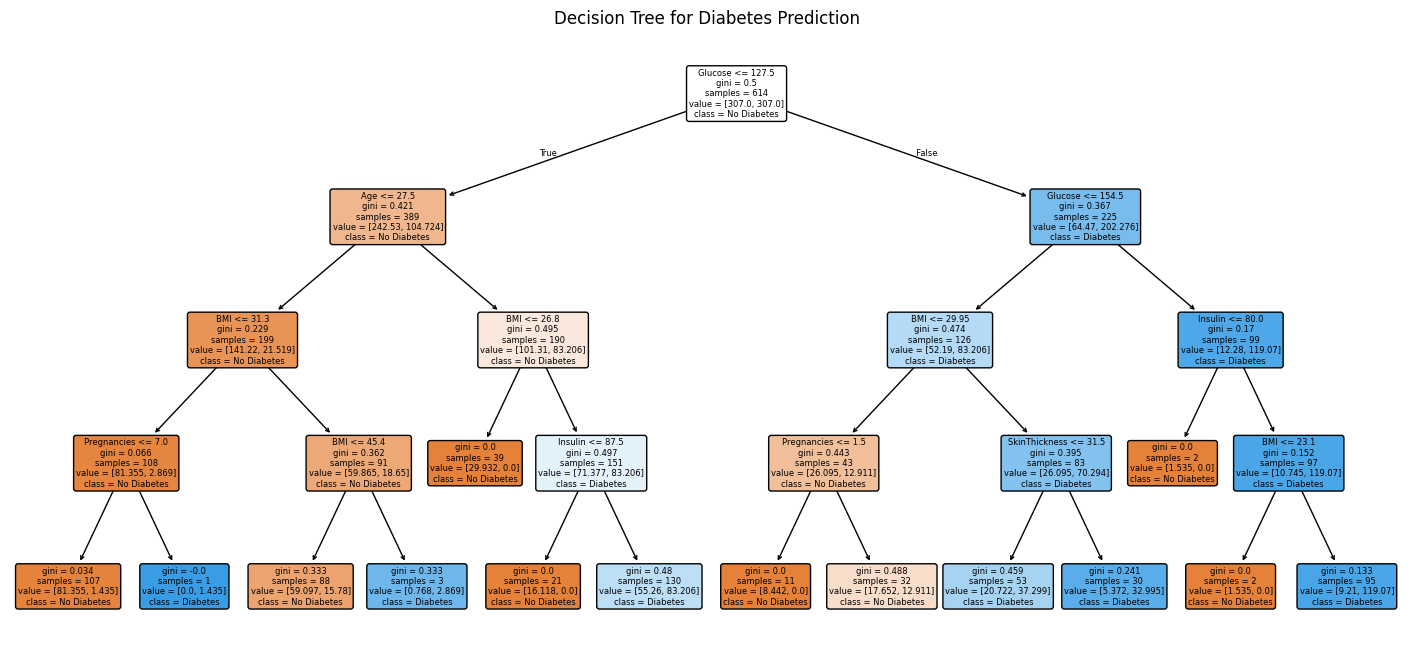

In [63]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))

plot_tree(
    decision_tree_model,
    feature_names=X_diabetes.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Diabetes Prediction")
plt.show()

# Predict Diabetes for Unknown Patient

## Step 29 — Create unknown patient data

In [64]:
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [145],
    "BloodPressure": [82],
    "SkinThickness": [30],
    "Insulin": [125],
    "BMI": [32.5],
    "DiabetesPedigreeFunction": [0.45],
    "Age": [35]
})

new_patient

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,145,82,30,125,32.5,0.45,35


## Step 30 — Predict unknown patient

In [65]:
patient_prediction = decision_tree_model.predict(
    new_patient
)[0]

print("Predicted class:", patient_prediction)

if patient_prediction == 1:
    print("Result: Diabetes")
else:
    print("Result: No Diabetes")

Predicted class: 1
Result: Diabetes


# Project 3 — Iris Flower Clustering

## Task

Group similar flowers without using a target variable.

## Dataset

Iris dataset

## Model

K-Means Clustering

## Step 1 — Give the Iris dataset path

In [66]:
iris_path = "datasets/iris.csv"

# Windows example:
# iris_path = r"C:\Users\Student\Downloads\iris.csv"

## Step 2 — Load the Iris dataset

In [67]:
iris = pd.read_csv(iris_path)

print("Iris dataset loaded successfully.")

Iris dataset loaded successfully.


## Step 3 — Display first five rows

In [68]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species_number,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Step 4 — Display last five rows

In [69]:
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species_number,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


## Step 5 — Display rows and columns

In [70]:
print("Rows:", iris.shape[0])
print("Columns:", iris.shape[1])

Rows: 150
Columns: 6


## Step 6 — Display column names

In [71]:
print(iris.columns.tolist())

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species_number', 'species']


## Step 7 — Display dataset information

In [72]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sepal_length    150 non-null    float64
 1   sepal_width     150 non-null    float64
 2   petal_length    150 non-null    float64
 3   petal_width     150 non-null    float64
 4   species_number  150 non-null    int64  
 5   species         150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


## Step 8 — Display statistical description

In [73]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width,species_number
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Step 9 — Check missing values

In [74]:
iris.isnull().sum()

sepal_length      0
sepal_width       0
petal_length      0
petal_width       0
species_number    0
species           0
dtype: int64

## Step 10 — Select clustering input columns

In [75]:
iris_features = iris[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
].copy()

iris_features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Step 11 — Plot feature distribution

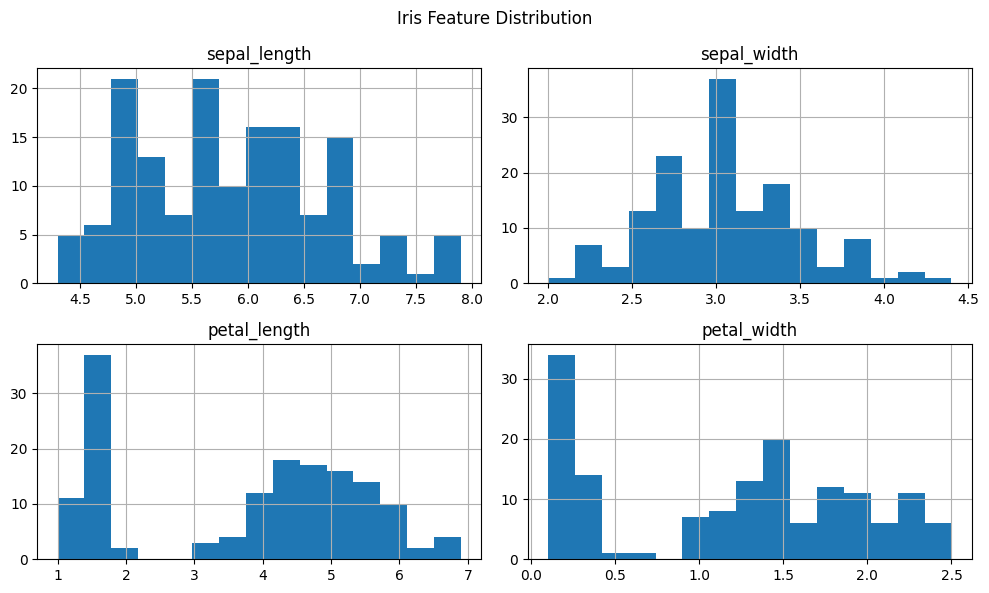

In [76]:
iris_features.hist(
    bins=15,
    figsize=(10, 6)
)

plt.suptitle("Iris Feature Distribution")
plt.tight_layout()
plt.show()

## Step 12 — Fill missing values using median

In [77]:
for column in iris_features.columns:
    iris_features[column] = iris_features[column].fillna(
        iris_features[column].median()
    )

## Step 13 — Standardize the input features

In [78]:
iris_scaler = StandardScaler()

iris_scaled = iris_scaler.fit_transform(
    iris_features
)

## Step 14 — Use elbow method

In [79]:
from sklearn.cluster import KMeans

inertia_values = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(iris_scaled)

    inertia_values.append(model.inertia_)

## Step 15 — Plot elbow graph

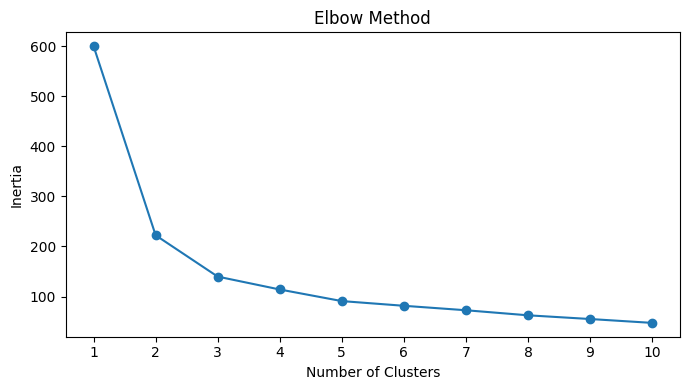

In [80]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, 11),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

## Step 16 — Train K-Means with 3 clusters

In [81]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

iris_clusters = kmeans_model.fit_predict(
    iris_scaled
)

## Step 17 — Add cluster labels to the dataset

In [82]:
iris_clustered = iris.copy()

iris_clustered["Cluster"] = iris_clusters

iris_clustered.head()

,sepal_length,sepal_width,petal_length,petal_width,species_number,species,Cluster
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1


## Step 18 — Plot clusters

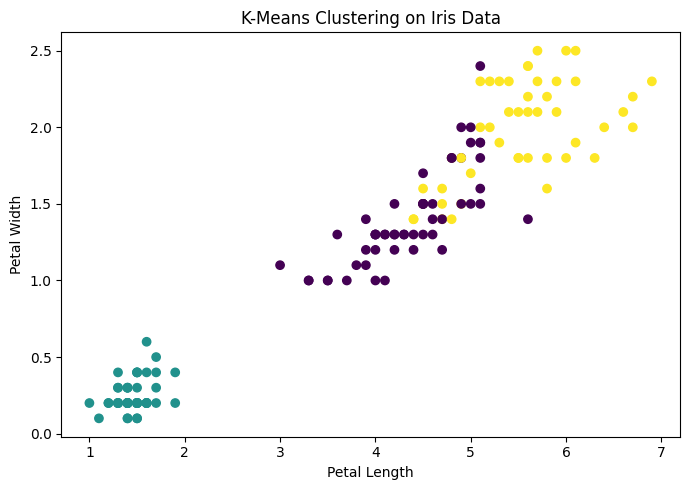

In [83]:
plt.figure(figsize=(7, 5))

plt.scatter(
    iris_clustered["petal_length"],
    iris_clustered["petal_width"],
    c=iris_clustered["Cluster"]
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering on Iris Data")
plt.tight_layout()
plt.show()

## Step 19 — Calculate silhouette score

In [84]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    iris_scaled,
    iris_clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518646


# Predict Cluster for Unknown Flower

## Step 20 — Create unknown flower data

In [85]:
new_flower = pd.DataFrame({
    "sepal_length": [5.8],
    "sepal_width": [2.7],
    "petal_length": [4.1],
    "petal_width": [1.0]
})

new_flower

,sepal_length,sepal_width,petal_length,petal_width
0,5.8,2.7,4.1,1.0


## Step 21 — Standardize unknown flower

In [86]:
new_flower_scaled = iris_scaler.transform(
    new_flower
)

## Step 22 — Predict flower cluster

In [87]:
flower_cluster = kmeans_model.predict(
    new_flower_scaled
)[0]

print("Predicted cluster:", flower_cluster)

Predicted cluster: 0


# Scikit-Learn Notebook Summary

This notebook covered:

1. Insurance regression using Linear Regression
2. Diabetes classification using Decision Tree
3. Iris clustering using K-Means
